In [24]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score,KFold,GroupKFold
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, classification_report,
                             confusion_matrix, accuracy_score,ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, roc_auc_score,roc_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from google.colab import files
uploaded=files.upload()

Saving breast-cancer-wisconsin-data_data.csv to breast-cancer-wisconsin-data_data.csv


In [3]:
df=pd.read_csv("breast-cancer-wisconsin-data_data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [5]:
df.shape

(569, 33)

In [4]:
#checcking the number of category and numerical columns
category=df.select_dtypes(include="object").columns.tolist()
print(category)
numeric=df.select_dtypes(include=["int64","float64"]).columns.tolist()
print(numeric)

['diagnosis']
['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
#checking for duplicates and missing values
print("duplicates is=",df.duplicated().sum())
print("missing_values=",df.isnull().sum())

duplicates is= 0
missing_values= id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fracta

In [8]:
df=df.drop(columns=["id","Unnamed: 32"])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [9]:
X=df.drop(columns=["diagnosis"])
y=df["diagnosis"].map({"B":0,"M":1})

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
#scaling training set then applying it to test set
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [12]:
model_lr=LogisticRegression(max_iter=1000)
model_dt=DecisionTreeClassifier( criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model_rf=RandomForestClassifier(n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1)
model_gb=GradientBoostingClassifier(n_estimators=100,max_depth=None,
                                 learning_rate=0.2,min_samples_split=20,min_samples_leaf=5,
                                 max_features=2,random_state=42)

In [30]:
results=[]
model_results={}
models={"LogisticRegression":model_lr,"DecisionTree":model_dt,"RandomForest":model_rf,"GradientBoosting":model_gb}
kf=KFold(n_splits=5,shuffle=True,random_state=42)
for name,model in models.items():
  model.fit(X_train_scaled,y_train)
  prediction=model.predict(X_test_scaled)
  probability=model.predict_proba(X_test_scaled)[:,1]
  cv_score=cross_val_score(model,X_train_scaled,y_train,cv=kf,scoring="roc_auc")
  auc_score=roc_auc_score(y_test,probability)
  results.append({"Model":name,
                  "Accuracy":accuracy_score(y_test,prediction),
                  "Precision":precision_score(y_test,prediction),
                  "Recall":recall_score(y_test,prediction),
                  "F1-Score":f1_score(y_test,prediction),
                  "AUC":auc_score,
                  "CV-mean":cv_score.mean(),"CV-std":cv_score.std()})
  model_results[name] = {'model': model, 'pred': prediction, 'prob': probability,'auc':auc_score}
results_df=pd.DataFrame(results)
results_df.sort_values(by='AUC',ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,CV-mean,CV-std
3,GradientBoosting,0.964912,1.000000,0.904762,0.950000,0.998016,0.994376,0.002684
0,LogisticRegression,0.964912,0.975000,0.928571,0.951220,0.996032,0.994505,0.004650
2,RandomForest,0.964912,1.000000,0.904762,0.950000,0.995040,0.989172,0.007430
1,DecisionTree,0.903509,0.918919,0.809524,0.860759,0.971561,0.947349,0.025460


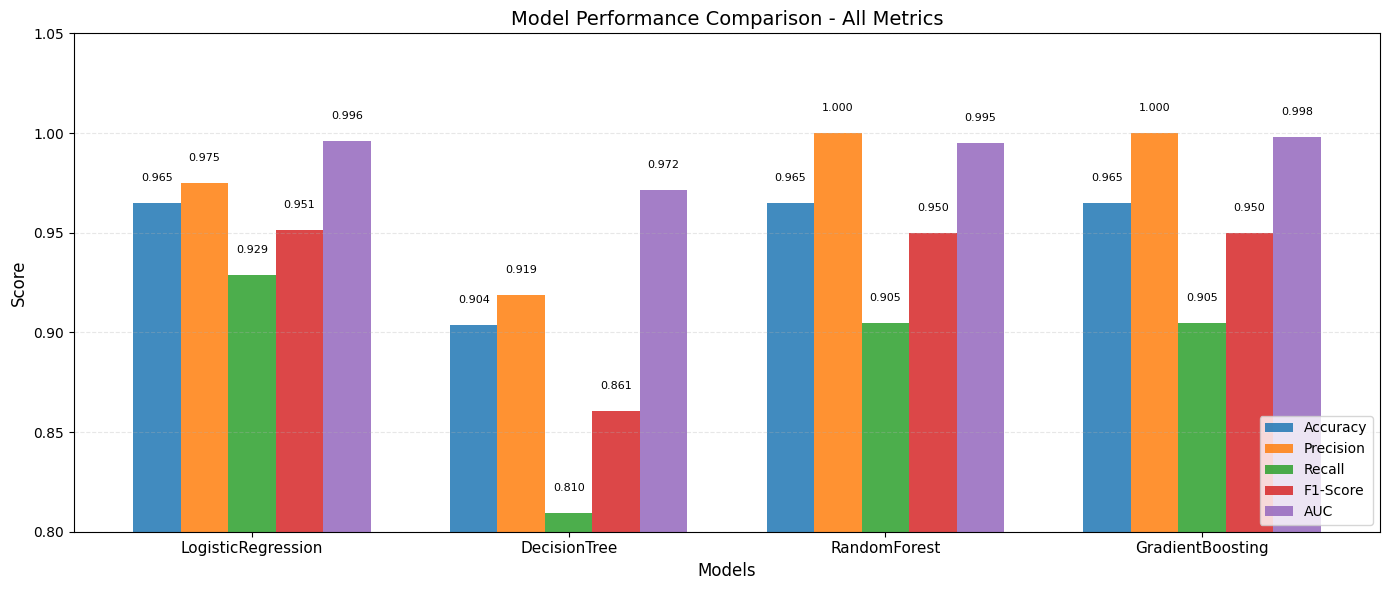

In [27]:
#visualizing model metrics and comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data
models = results_df['Model'].tolist()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

# Set bar positions
x = np.arange(len(models))
width = 0.15  # Width of each bar

# Plot each metric as a group of bars
for i, metric in enumerate(metrics):
    values = results_df[metric].tolist()
    ax.bar(x + (i * width), values, width, label=metric, alpha=0.85)

# Customize chart
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - All Metrics', fontsize=14)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(models, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim([0.8, 1.05])  # Set y-axis limits
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, metric in enumerate(metrics):
    values = results_df[metric].tolist()
    for j, v in enumerate(values):
        ax.text(j + (i * width), v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

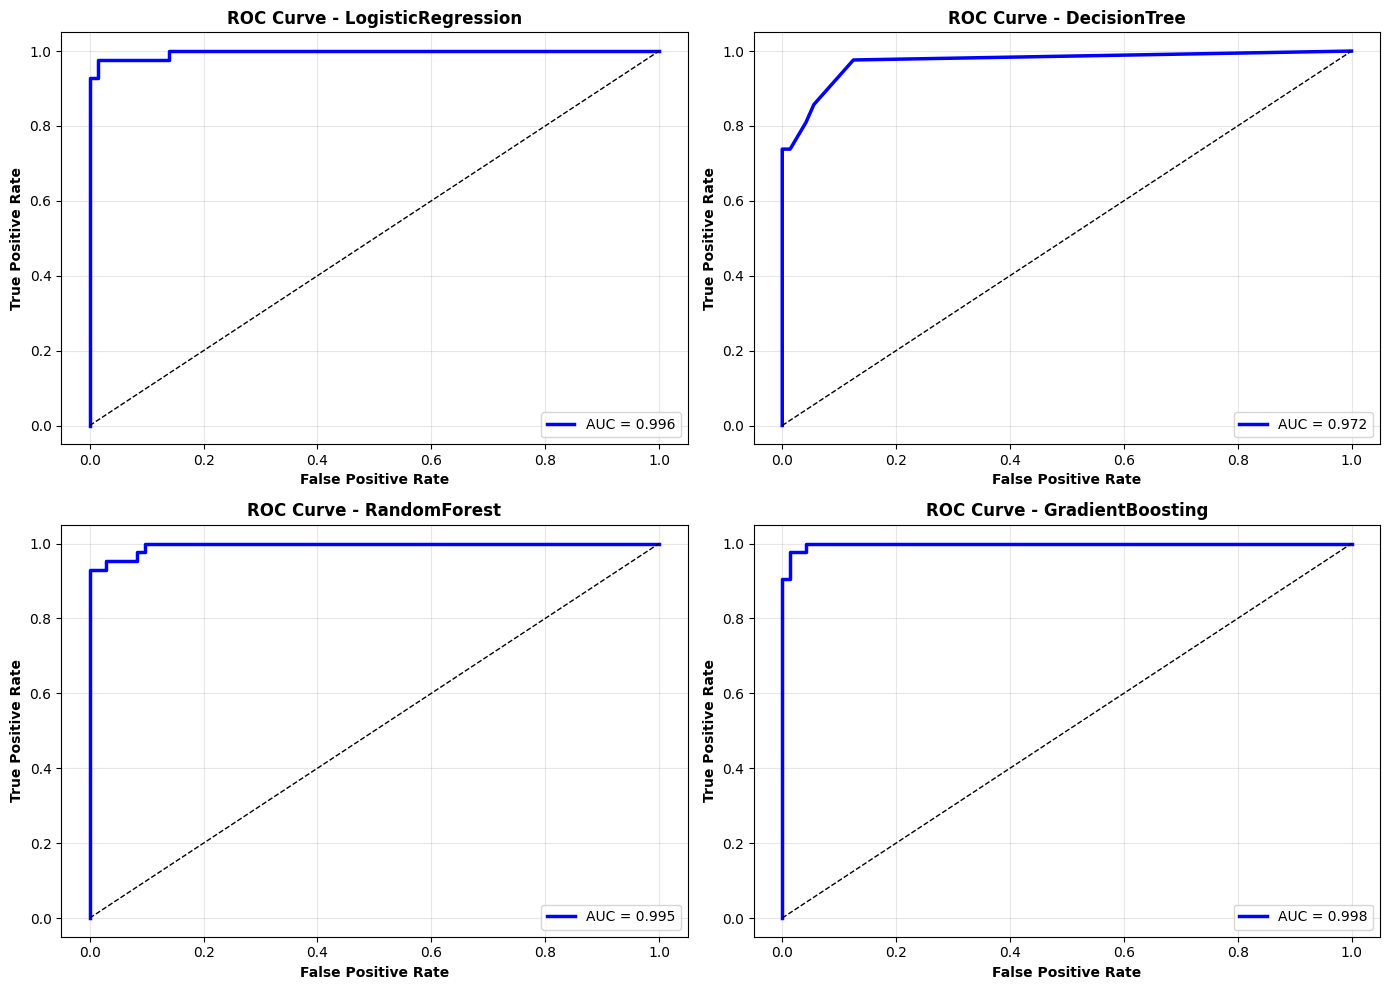

In [32]:
#ROC curve visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model_data) in enumerate(model_results.items()):
    fpr, tpr, _ = roc_curve(y_test, model_data['prob'])
    auc_score = model_data['auc']

    axes[idx].plot(fpr, tpr,
                   color='blue',
                   linewidth=2.5,
                   label=f'AUC = {auc_score:.3f}')
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1)

    axes[idx].set_xlabel('False Positive Rate', fontweight='bold')
    axes[idx].set_ylabel('True Positive Rate', fontweight='bold')
    axes[idx].set_title(f'ROC Curve - {name}', fontweight='bold')
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Confusion Matrix**

In [17]:
confusionmatrix=[]
models={"LogisticRegression":model_lr,"DecisionTree":model_dt,"RandomForest":model_rf,"GradientBoosting":model_gb}
for name,model in models.items():
  model.fit(X_train_scaled,y_train)
  prediction=model.predict(X_test_scaled)
  cm=confusion_matrix(y_test,prediction)
  confusionmatrix.append({"Model":name,
                  "ConfusionMatrix":cm,})
confusionmatrix_df=pd.DataFrame(confusionmatrix)
confusionmatrix_df

,Model,ConfusionMatrix
0,LogisticRegression,"[[71, 1], [3, 39]]"
1,DecisionTree,"[[69, 3], [8, 34]]"
2,RandomForest,"[[72, 0], [4, 38]]"
3,GradientBoosting,"[[72, 0], [4, 38]]"


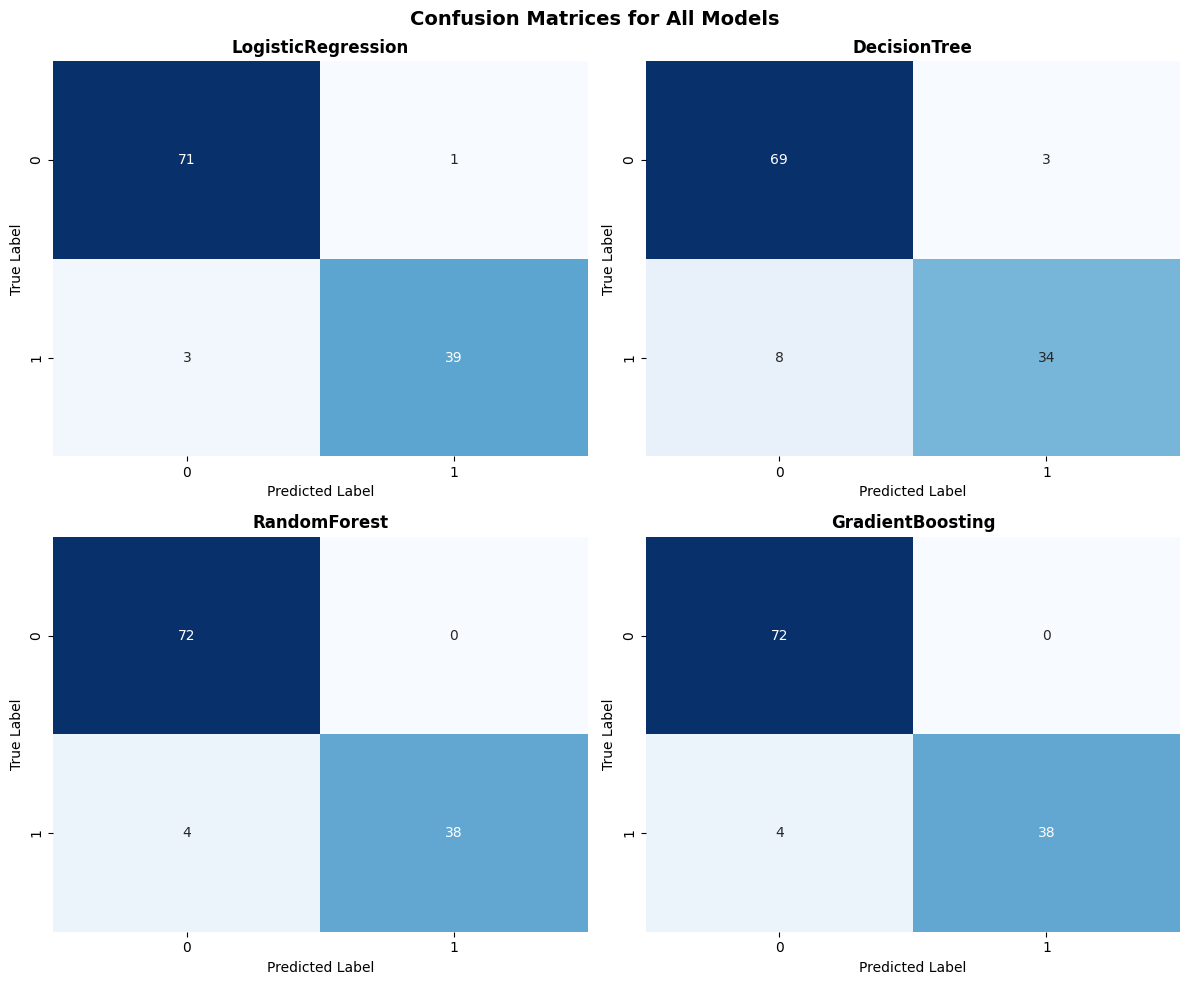

In [26]:
#confusion matrix visualization
models={"LogisticRegression":model_lr,"DecisionTree":model_dt,"RandomForest":model_rf,"GradientBoosting":model_gb}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold')

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx // 2, idx % 2]
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

**Hyperparameter Tuning**

In [ ]:
#hyperparameter tuning for RandomForestClassifier
param_grid={"n_estimators":[100,200,300,500],"min_samples_split":[5,10,15,20],
            "min_samples_leaf":[2,5,8,10],
            "max_depth":[None,5,10,20]}
grid=GridSearchCV(estimator=model_rf,param_grid=param_grid,cv=5,scoring="roc_auc")
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                              random_state=42),
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [2, 5, 8, 10],
                         'min_samples_split': [5, 10, 15, 20],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='roc_auc')

In [ ]:
#best parameter for RandomForestClassifier
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
0.9904024767801858


In [ ]:
#hyperparameter tuning for GradientBoosting classifier
param_grid={"n_estimators":[100,200,300,500],"min_samples_split":[5,10,15,20],
            "min_samples_leaf":[2,5,8,10],
            "max_depth":[None,5,10,20],"learning_rate":[0.1,0.2,0.3,0.4]}
grid=GridSearchCV(estimator=model_gb,param_grid=param_grid,cv=5,scoring="roc_auc")
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=GradientBoostingClassifier(max_depth=250, max_features=2,
                                                  min_samples_leaf=10,
                                                  min_samples_split=15,
                                                  random_state=42),
             param_grid={'learning_rate': [0.1, 0.2, 0.3, 0.4],
                         'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [2, 5, 8, 10],
                         'min_samples_split': [5, 10, 15, 20],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='roc_auc')

In [ ]:
#best parameters for GradientBoostingClassifier
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.2, 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}
0.9944272445820432


**Feature Importance**

In [18]:
#Feature Importance for RandomForest
importance=model_rf.feature_importances_
importance_rf=pd.DataFrame({"Features":X_train.columns,
                            "Importance":importance})
importance_rf.sort_values(by="Importance",ascending=False)
print(importance_rf.head(10))


                 Features  Importance
0             radius_mean    0.060063
1            texture_mean    0.013084
2          perimeter_mean    0.061056
3               area_mean    0.046358
4         smoothness_mean    0.006928
5        compactness_mean    0.017863
6          concavity_mean    0.043957
7     concave points_mean    0.093629
8           symmetry_mean    0.004093
9  fractal_dimension_mean    0.003455


In [19]:
#feature importance for GradientBoosting
importance=model_gb.feature_importances_
importance_gb=pd.DataFrame({"Features":X_train.columns,
                            "Importance":importance})
print(importance_gb.sort_values(by="Importance",ascending=False).head(10).reset_index(drop=True))


               Features  Importance
0            area_worst    0.181197
1   concave points_mean    0.131246
2               area_se    0.110908
3        symmetry_worst    0.071937
4             area_mean    0.063681
5          radius_worst    0.051854
6  concave points_worst    0.050649
7             radius_se    0.043059
8      compactness_mean    0.040199
9        perimeter_mean    0.034630


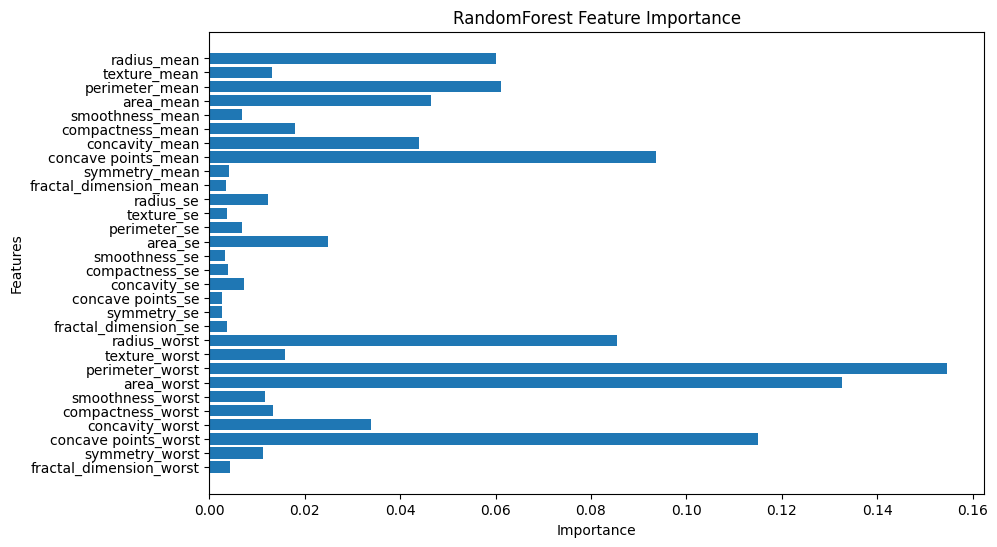

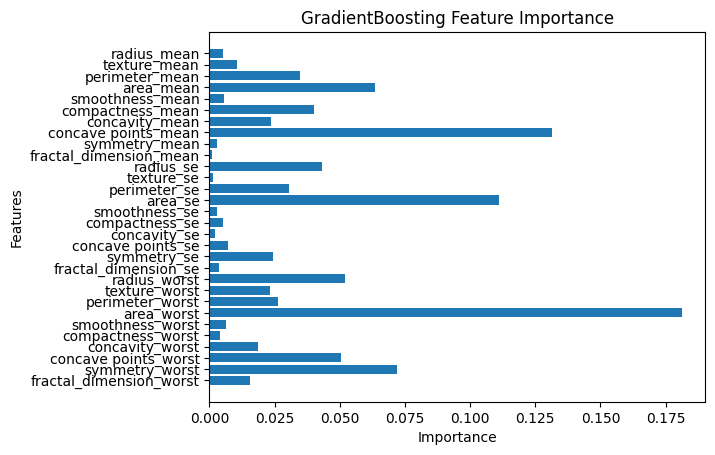

In [20]:
#feature importance visualization
plt.figure(figsize=(10, 6))
models={"RandomForest":importance_rf,"GradientBoosting":importance_gb}
for name,important in models.items():
  plt.barh(
   important["Features"],
   important["Importance"]
)

  plt.xlabel("Importance")
  plt.ylabel("Features")
  plt.title(f"{name} Feature Importance")

  plt.gca().invert_yaxis()

  plt.show()



**CONCLUSION**

In [34]:
# Re-create the models dictionary with the actual model objects
current_models = {
    "LogisticRegression": model_lr,
    "DecisionTree": model_dt,
    "RandomForest": model_rf,
    "GradientBoosting": model_gb
}
# Find the model name corresponding to the best accuracy, F1-Score, and ROC-AUC
best_model_accuracy_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_model_f1_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model_auc_name = results_df.loc[results_df['AUC'].idxmax(), 'Model']

print("Best Model based on Accuracy:", best_model_accuracy_name)
print("Best Model based on F1-Score:", best_model_f1_name)
print("Best Model based on ROC-AUC:", best_model_auc_name)

#best model object based on ROC-AUC (as 'best_overall_model')
best_overall_model = current_models[best_model_auc_name]

# Classification report of the best model
print(classification_report(y_test, best_overall_model.predict(X_test)))

Best Model based on Accuracy: LogisticRegression
Best Model based on F1-Score: LogisticRegression
Best Model based on ROC-AUC: GradientBoosting
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.37      1.00      0.54        42

    accuracy                           0.37       114
   macro avg       0.18      0.50      0.27       114
weighted avg       0.14      0.37      0.20       114



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicte